# 04 의사결정

모델 예측 결과를 위험도 3단계로 분류하고,
고위험군 페르소나와 예방 정책 시나리오 4개를 데이터 수치 기반으로 제시한다.

## 섹션 1 — 데이터 및 모델 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
from sklearn.metrics import precision_recall_curve, roc_auc_score, recall_score

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

best_model = joblib.load('../outputs/models/best_model.pkl')
X_train, X_test, y_train, y_test = joblib.load('../outputs/models/train_test_split.pkl')

df = pd.read_csv('../data/diabetes_indicators.csv')
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

feature_names = X.columns.tolist()
X_test_model = pd.DataFrame(X_test, columns=feature_names)

print(f'전체 데이터: {len(df):,}행')
print(f'테스트셋 크기: {len(y_test):,}행')

전체 데이터: 253,680행
테스트셋 크기: 50,736행


## 섹션 2 — 위험 점수 산출 및 3단계 분류

위험 단계별 인원:
risk_tier
low       24210
medium    13494
high      13032
Name: count, dtype: int64

위험 단계별 비율:
risk_tier
low       0.477
medium    0.266
high      0.257
Name: proportion, dtype: float64


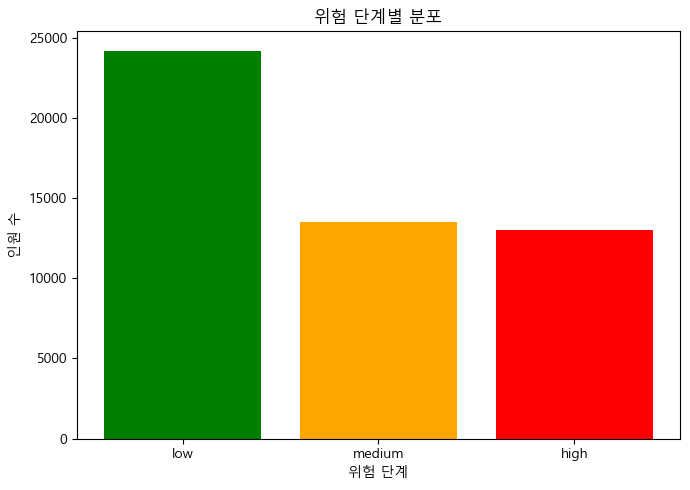

In [2]:
y_prob = best_model.predict_proba(X_test_model)[:, 1]

prob_df = pd.DataFrame({
    'prob': y_prob,
    'actual': y_test.values if hasattr(y_test, 'values') else y_test,
})

def classify_risk(prob):
    if prob >= 0.6:
        return 'high'
    elif prob >= 0.3:
        return 'medium'
    return 'low'

prob_df['risk_tier'] = prob_df['prob'].apply(classify_risk)

tier_counts = prob_df['risk_tier'].value_counts()
tier_ratios = prob_df['risk_tier'].value_counts(normalize=True).round(3)

print('위험 단계별 인원:')
print(tier_counts)
print('\n위험 단계별 비율:')
print(tier_ratios)

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'low': 'green', 'medium': 'orange', 'high': 'red'}
for tier in ['low', 'medium', 'high']:
    count = tier_counts.get(tier, 0)
    ax.bar(tier, count, color=colors[tier])
ax.set_title('위험 단계별 분포')
ax.set_xlabel('위험 단계')
ax.set_ylabel('인원 수')
plt.tight_layout()
plt.savefig('../outputs/figures/04_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 3 — 그룹별 피처 평균 비교

In [3]:
test_indices = y_test.index if hasattr(y_test, 'index') else range(len(y_test))
X_test_df = pd.DataFrame(X_test, columns=feature_names, index=test_indices)
X_test_df['risk_tier'] = prob_df['risk_tier'].values

group_means = X_test_df.groupby('risk_tier').mean().round(3)
print('그룹별 피처 평균:')
print(group_means.T)

그룹별 피처 평균:
risk_tier              high    low  medium
HighBP                0.891 -0.617   0.248
HighChol              0.644 -0.453   0.184
CholCheck             0.186 -0.164   0.138
BMI                   0.717 -0.429   0.089
Smoker                0.205 -0.144   0.072
Stroke                0.350 -0.163  -0.031
HeartDiseaseorAttack  0.572 -0.274  -0.066
PhysActivity         -0.379  0.210  -0.030
Fruits               -0.123  0.078  -0.028
Veggies              -0.169  0.104  -0.024
HvyAlcoholConsump    -0.184  0.151  -0.055
AnyHealthcare         0.043 -0.043   0.027
NoDocbcCost           0.102 -0.056  -0.028
GenHlth               0.957 -0.589   0.125
MentHlth              0.177 -0.094  -0.016
PhysHlth              0.502 -0.271  -0.018
DiffWalk              0.677 -0.344  -0.033
Sex                   0.087 -0.095   0.061
Age                   0.599 -0.498   0.310
Education            -0.398  0.248  -0.050
Income               -0.507  0.304  -0.027


## 고위험군 페르소나

**"당뇨 고위험 프로파일"**

| 항목 | 고위험군 평균(표준화) | 저위험군 평균(표준화) |
|------|----------------------|----------------------|
| BMI | 0.717 | -0.429 |
| HighBP | 0.891 | -0.617 |
| PhysActivity | -0.379 | 0.210 |
| Age | 0.599 | -0.498 |
| GenHlth | 0.957 | -0.589 |

→ 대표 페르소나: 표준화 기준 BMI·GenHlth 높음, 신체 활동 부족, 고혈압 해당

## 섹션 4 — 정책 시나리오

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

batch_size = 50000
all_probs = []
for i in range(0, len(X_scaled), batch_size):
    batch = X_scaled[i:i + batch_size]
    probs = best_model.predict_proba(batch)[:, 1]
    all_probs.extend(probs)

df['risk_prob'] = all_probs
df['risk_tier'] = pd.cut(
    df['risk_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['low', 'medium', 'high'],
    include_lowest=True,
)

total = len(df)

scenario_a = (df['risk_tier'] == 'high').sum()
print(f'시나리오 A 대상: {scenario_a:,}명 ({scenario_a/total:.1%})')

scenario_b = ((df['risk_tier'] == 'high') & (df['BMI'] >= 30)).sum()
print(f'시나리오 B 대상: {scenario_b:,}명 ({scenario_b/total:.1%})')

scenario_c = ((df['risk_tier'].isin(['medium', 'high'])) & (df['PhysActivity'] == 0)).sum()
print(f'시나리오 C 대상: {scenario_c:,}명 ({scenario_c/total:.1%})')

scenario_d = ((df['risk_tier'].isin(['medium', 'high'])) & (df['Smoker'] == 1) & (df['HighBP'] == 1)).sum()
print(f'시나리오 D 대상: {scenario_d:,}명 ({scenario_d/total:.1%})')

시나리오 A 대상: 64,265명 (25.3%)
시나리오 B 대상: 39,784명 (15.7%)
시나리오 C 대상: 43,327명 (17.1%)
시나리오 D 대상: 48,071명 (18.9%)


C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: 

## 시나리오별 정책 대상

| 시나리오 | 대상 | 개입 방식 | 대상 인원 | 비율 |
|---------|------|----------|-----------|------|
| A | 고위험군 전체 | 정기 혈당 검사 의무화 | 64,265명 | 25.3% |
| B | BMI ≥ 30 + 고위험 | 체중 관리 프로그램 연계 | 39,784명 | 15.7% |
| C | 운동 부족 + 중/고위험 | 지역 운동 프로그램 무료 제공 | 43,327명 | 17.1% |
| D | 흡연+고혈압 복합 + 중/고위험 | 금연·혈압 관리 패키지 | 48,071명 | 18.9% |

## 섹션 5 — 임계값 트레이드오프

기본 임계값 Recall: 0.761
F1 최대 임계값: 0.609
Recall >= 0.8 보장 임계값: 0.460


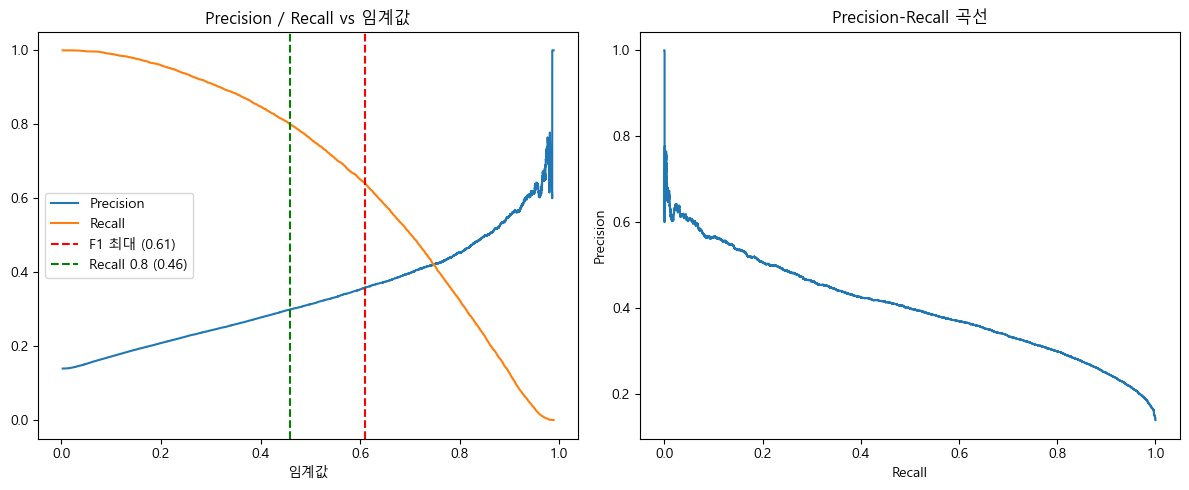

In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_f1_thresh = thresholds[np.argmax(f1_scores[:-1])]
recall_80_idx = np.where(recall[:-1] >= 0.8)[0]
recall_80_thresh = thresholds[recall_80_idx[-1]] if len(recall_80_idx) > 0 else None
model_recall = recall_score(y_test, best_model.predict(X_test_model))

print(f'기본 임계값 Recall: {model_recall:.3f}')
print(f'F1 최대 임계값: {best_f1_thresh:.3f}')
print(f'Recall >= 0.8 보장 임계값: {recall_80_thresh:.3f}' if recall_80_thresh is not None else 'Recall 0.8 달성 임계값 없음')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thresholds, precision[:-1], label='Precision')
axes[0].plot(thresholds, recall[:-1], label='Recall')
axes[0].axvline(x=best_f1_thresh, color='red', linestyle='--', label=f'F1 최대 ({best_f1_thresh:.2f})')
if recall_80_thresh is not None:
    axes[0].axvline(x=recall_80_thresh, color='green', linestyle='--', label=f'Recall 0.8 ({recall_80_thresh:.2f})')
axes[0].set_xlabel('임계값')
axes[0].set_title('Precision / Recall vs 임계값')
axes[0].legend()

axes[1].plot(recall[:-1], precision[:-1])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall 곡선')

plt.tight_layout()
plt.savefig('../outputs/figures/04_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 조기 개입 효과 추정

- 전체 데이터 중 고위험군(64,265명, 25.3%)에 대한 조기 개입 가능
- 현재 모델 Recall 기준 그 중 약 76.1%를 발병 전 탐지 가능
- F1 최대 임계값 0.609: Precision과 Recall의 균형점
- Recall 0.8 보장 임계값 0.460: 더 많은 위험군 탐지, Precision 하락

→ **권장 임계값**: 0.460 — 당뇨 미탐지 비용이 오탐지 비용보다 크므로 Recall 우선